In [231]:
import numpy as np
import random as rand
import matplotlib.pyplot as plt

In [232]:
# CONSTANTS
POINT_AMOUNT = 200
UPPER_RANGE = 40

In [233]:
class Line:
    def __init__(self, m: int, b: int):
        self.m = m
        self.b = b

    def solve(self, x) -> int:
        # print(f"M value of {self.m}, B value of {self.b}, X value of {x}")
        return (self.m * x) + self.b

    def intercept(self, coord) -> bool:
        return self.solve(coord[0]) == coord[1]

    def get_m(self):
        return self.m

    def get_b(self):
        return self.b
    
    def set_new(self, m: float, b: float):
        self.m = m
        self.b = b
        
# line = Line(1, 0)
# line.solve(2)

In [234]:
class Point:
    def __init__(self, x: int, y: int):
        self.x = x
        self.y = y

    def get_x(self):
        return self.x

    def get_y(self):
        return self.y
        
    def get_coord(self):
        return (self.x, self.y)

In [235]:
def generate_points(upperbound_x: int, upperbound_y: int):
    return [Point(rand.randint(0, upperbound_x), rand.randint(0, upperbound_y)) for i in range(POINT_AMOUNT)]

In [236]:
def calculate_residuals(line: Line, points):
    residuals = []
    for point in points:
        x_1 = point.get_x()
        y_1 = point.get_y()
        y_2 = line.solve(x_1)
        diff = y_2 - y_1
        residuals.append(diff)
        # print("Added diff of:", diff)
    # print("Resulting residuals are: ", residuals)
    return residuals

# SSE = Sum Squared Error. This is our loss
def calculateSSE(residuals):
    sum = 0
    for residual in residuals:
        squared = residual**2
        sum += squared
    # print("SSE: ", sum)
    return sum

def calculateMSE(SSE, num=POINT_AMOUNT):
    MSE = SSE / num
     # print("MSE: ", MSE)
    return MSE

def calculate_sum_error(residuals):
    sum = 0
    for residual in residuals:
        sum += residual
    # print("SUM: ", sum)
    return sum

def calculate_sum_error_x(residuals, points):
    sum = 0
    for index, x in enumerate(points):
        sum += residuals[index] * points[index].get_x()
    # print("Sum Error X: ", sum)
    return sum

In [237]:
# Setup
line = Line(1, 0)
points = generate_points(UPPER_RANGE, UPPER_RANGE)

In [238]:
for step in range(100):
    # calculate residuals
    residuals = calculate_residuals(line=line, points=points)
    SSE = calculateSSE(residuals)
    SE = calculate_sum_error(residuals)
    SE_X = calculate_sum_error_x(residuals, points)
    MSE = calculateMSE(SSE)
    
    # calculate gradient
    grad_w = (2 / POINT_AMOUNT) * SE_X
    grad_b = (2 / POINT_AMOUNT) * SE

    print(f"Weight Grad: {grad_w}. Bias Grad: {grad_b}")
    print("MSE: ", MSE)

    new_m = line.get_m() - grad_w * 0.01
    new_b = line.get_b() - grad_b * 0.01
    
    line.set_new(new_m, new_b)
    
generated_line = [[0, line.solve(0)], [UPPER_RANGE, line.solve(UPPER_RANGE)]]

Weight Grad: 146.99. Bias Grad: -5.34
MSE:  261.53
Weight Grad: -1226.894495000001. Bias Grad: -58.281890999999995
MSE:  1053.5071041105505
Weight Grad: 10277.749223212406. Bias Grad: 385.6699700655003
MSE:  56671.13029124718
Weight Grad: -86060.14402333008. Bias Grad: -3331.283123993165
MSE:  3956713.54942617
Weight Grad: 720656.4581000864. Bias Grad: 27794.448516506527
MSE:  277431433.130184
Weight Grad: -6034646.940540521. Bias Grad: -232846.35618214472
MSE:  19453735753.84978
Weight Grad: 50533079.208170824. Bias Grad: 1949714.6517825718
MSE:  1364114209100.7502
Weight Grad: -423155140.8902152. Bias Grad: -16326667.927481916
MSE:  95652969779802.34
Weight Grad: 3543426956.7831335. Bias Grad: 136716555.77834642
MSE:  6707276097733332.0
Weight Grad: -29672036020.99175. Bias Grad: -1144840564.0402534
MSE:  4.703205008155926e+17
Weight Grad: 248468426891.45102. Bias Grad: 9586694047.21647
MSE:  3.297931533818799e+19
Weight Grad: -2080631039851.48. Bias Grad: -80277295098.85252
MSE:  2.

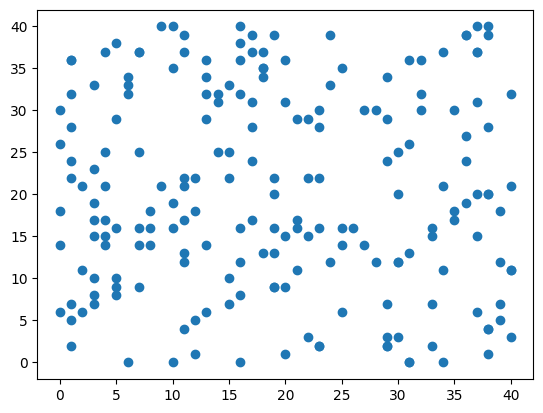

In [227]:
points_expanded = [[points[i].get_x(), points[i].get_y()] for i in range(len(points))]
x_values = [points[i].get_x() for i in range(len(points))]
y_values = [points[i].get_y() for i in range(len(points))]

plt.scatter(x_values, y_values)
# plt.plot(
#     [0, UPPER_RANGE],
#     [line.solve(0), line.solve(UPPER_RANGE)]
# )